In [ ]:
import networkx as nx
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
from sentence_transformers import SentenceTransformer
from adjustText import adjust_text
import ast
import matplotlib.pyplot as plt
from urlextract import URLExtract
import requests
import tldextract

In [ ]:
moldova_df = pd.read_csv('..dataset/moldova.csv')

In [ ]:
def getContrastingStances(row):
    stances = []
    if row['pro-Russia'] == 'yes':
        stances.append('pro-Russia')
    if row['anti-Russia'] == 'yes':
        stances.append('anti-Russia')

    if row['pro-Europe'] == 'yes':
        stances.append('pro-Europe')
    if row['anti-Europe'] == 'yes':
        stances.append('anti-Europe')

    if not stances:
        return 'neutral'
    elif len(stances) == 1:
        return stances[0]
    else:
        return ' & '.join(sorted(stances))
    
moldova_df['contrasting_stance'] = moldova_df.apply(getContrastingStances, axis=1)
moldova_df['contrasting_stance'].value_counts()

### Helper functions for gephi format

In [ ]:
def _mode_or_none(s: pd.Series):
    s = s.dropna()
    return s.value_counts().idxmax() if not s.empty else None

def build_user_attributes(df,
                          user_col="twitterData.twitterAuthorScreenname",
                          lang_col="language",
                          stance_col="contrasting_stance"):
    # keep only rows with a user id
    tmp = df[df[user_col].notna()][[user_col, lang_col, stance_col]].copy()
    grp = tmp.groupby(user_col, dropna=True)

    lang_map  = grp[lang_col].apply(_mode_or_none).to_dict()
    topic_map = grp[stance_col].apply(_mode_or_none).to_dict()
    return lang_map, topic_map

def enrich_grr_nodes_with_meta(G, df,
                               user_col="twitterData.twitterAuthorScreenname",
                               lang_col="language",
                               stance_col="contrasting_stance"):
    lang_map, topic_map = build_user_attributes(df, user_col, lang_col, stance_col)
    # only set attributes for nodes present in G
    nx.set_node_attributes(G, {n: lang_map.get(n)  for n in G.nodes()}, name="language")
    nx.set_node_attributes(G, {n: topic_map.get(n) for n in G.nodes()}, name="stance")
    return G

def _is_nan(x):
    try:
        return isinstance(x, float) and math.isnan(x) or (isinstance(x, np.floating) and np.isnan(x))
    except Exception:
        return False

def sanitize_graph_for_gexf(G, none_policy="drop"):
    """
    Make all node/edge attributes GEXF-safe.
    none_policy: "drop"  -> remove attributes that are None/NaN
                 "string"-> replace with "unknown"
    Returns a COPY of G.
    """
    H = G.copy()

    # sanitize node attributes
    for n, attrs in list(H.nodes(data=True)):
        clean = {}
        for k, v in attrs.items():
            if v is None or _is_nan(v):
                if none_policy == "string":
                    clean[k] = "unknown"
                # else drop it by not copying
            elif isinstance(v, (list, dict, set, tuple)):
                clean[k] = str(v)  # flatten any container to string
            elif isinstance(v, (np.integer, np.int64, np.int32)):
                clean[k] = int(v)
            elif isinstance(v, (np.floating,)):
                if np.isfinite(v):
                    clean[k] = float(v)
                else:
                    continue  # drop inf/-inf
            else:
                clean[k] = v
        # replace attrs
        for k in list(attrs.keys()):
            del H.nodes[n][k]
        H.nodes[n].update(clean)

    # sanitize edge attributes (especially weight)
    for u, v, attrs in list(H.edges(data=True)):
        clean = {}
        for k, val in attrs.items():
            if val is None or _is_nan(val):
                if none_policy == "string":
                    clean[k] = "unknown"
                # else drop
            elif isinstance(val, (list, dict, set, tuple)):
                clean[k] = str(val)
            elif isinstance(val, (np.integer, np.int64, np.int32)):
                clean[k] = int(val)
            elif isinstance(val, (np.floating,)):
                if np.isfinite(val):
                    clean[k] = float(val)
                else:
                    continue
            else:
                clean[k] = val
        # replace attrs
        for k in list(attrs.keys()):
            del H[u][v][k]
        H[u][v].update(clean)

    return H


## Rapid retweet coordination network

In [ ]:
def prepare_rt_pairs(data):
    """
    Return pairs needed to build GRR:
      retweeter_id, orig_user_id, rt_time, orig_time, delta_t (seconds)
    Keeps ONLY rows where the parent/original tweet is present in df,
    since we need orig_time to compute Δt by definition.
    """
    df = data.copy()
    df["timePublished"] = pd.to_datetime(df["timePublished"], errors="coerce")

    # Originals: tweetId -> (authorId, time)
    originals = (
        df.loc[(~df["is_retweet"]) & df["twitterData.tweetId"].notna()],
        # columns
    )[0][["twitterData.tweetId", "twitterData.twitterAuthorScreenname", "timePublished"]].rename(
        columns={
            "twitterData.tweetId": "orig_tweet_id",
            "twitterData.twitterAuthorScreenname": "orig_user_id",
            "timePublished": "orig_time",
        }
    ).copy()
    originals["orig_tweet_id"] = originals["orig_tweet_id"].astype(str)

    # Retweets: need parent tweet id and retweeter id/time
    retweets = df.loc[
        df["is_retweet"] & df["twitterData.engagementParentId"].notna(),
        ["twitterData.engagementParentId", "twitterData.twitterAuthorScreenname", "timePublished"],
    ].rename(
        columns={
            "twitterData.engagementParentId": "orig_tweet_id",
            "twitterData.twitterAuthorScreenname": "retweeter_id",
            "timePublished": "rt_time",
        }
    ).copy()
    retweets["orig_tweet_id"] = retweets["orig_tweet_id"].astype(str)
    retweets["rt_time"] = pd.to_datetime(retweets["rt_time"], errors="coerce")

    # Inner join: only retweets whose parent tweet (with time) is present
    merged = retweets.merge(
        originals[["orig_tweet_id", "orig_user_id", "orig_time"]],
        on="orig_tweet_id",
        how="inner",
    )
    merged["delta_t"] = (merged["rt_time"] - merged["orig_time"]).dt.total_seconds()
    merged = merged.loc[merged["delta_t"].notna() & (merged["delta_t"] >= 0)]

    return merged

In [ ]:
def build_grr_network(merged, delta_t_seconds):
    subset = merged[merged["delta_t"] <= delta_t_seconds]
    G = nx.DiGraph()
    for row in subset.itertuples(index=False):
        u, v = row.orig_user_id, row.retweeter_id
        if u != v:
            if G.has_edge(u, v):
                G[u][v]["weight"] += 1
            else:
                G.add_edge(u, v, weight=1)
    return G, subset

merged = prepare_rt_pairs(moldova_df)
G_1h, subset_1h = build_grr_network(merged, 3600)

# Basic stats
def print_net_stats(G, label):
    n, m = G.number_of_nodes(), G.number_of_edges()
    density = m / (n * (n - 1)) if n > 1 else 0
    print(f"{label}: {n} nodes, {m} edges, density={density:.4g}")

print_net_stats(G_1h, "1h network")

# Top 10 rapid retweeters (by out-degree)
def top_out_degree(G, k=20):
    return sorted(G.out_degree(weight="weight"), key=lambda x: x[1], reverse=True)[:k]

# Top 10 rapidly retweeted (by in-degree)
def top_in_degree(G, k=20):
    return sorted(G.in_degree(weight="weight"), key=lambda x: x[1], reverse=True)[:k]

print("\nTop retweeted (3h):", top_out_degree(G_1h))
print("Top retweeters (3h):", top_in_degree(G_1h))

output hidden for anonymization purposes

In [ ]:
# largest WCC (by number of nodes)
largest_wcc_nodes = max(nx.weakly_connected_components(G_1h), key=len)
G_wcc = G_1h.subgraph(largest_wcc_nodes).copy()

In [ ]:
n = G_wcc.number_of_nodes()
m = G_wcc.number_of_edges()

avg_in  = m / n
avg_out = m / n
avg_tot = 2 * m / n

print(avg_in, avg_out, avg_tot)

1.1592437738592982 1.1592437738592982 2.3184875477185964


In [ ]:
wcc_size = len(max(nx.weakly_connected_components(G_1h), key=len))
wcc_size

5501

In [ ]:
G_1h = enrich_grr_nodes_with_meta(G_1h, moldova_df)
G_1h = sanitize_graph_for_gexf(G_1h, none_policy="string")
nx.write_gexf(G_1h, "rapid_retweet_1h.gexf")

## Rapid semantic similarity coordination network

In [ ]:
MENTION_RE = re.compile(r"@\w+")
URL_RE = re.compile(r"https?://\S+|www\.\S+")

def clean_for_embedding(text: str) -> str:
    if not isinstance(text, str):
        return ""
    t = MENTION_RE.sub("", text)
    t = URL_RE.sub("", t)
    return t.strip()

def build_grss(
    df: pd.DataFrame,
    text_col="ContentText",                
    user_col="twitterData.twitterAuthorScreenname",
    time_col="timePublished",           
    is_rt_col="is_retweet",
    dt_seconds=3600,                     
    sim_threshold=0.85,                  
    model_name="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    batch_size=256
):
    # exclude retweets
    use = df.loc[~df[is_rt_col].astype(bool), [text_col, user_col, time_col]].copy()
    use.dropna(subset=[text_col, user_col, time_col], inplace=True)

    # Sort by time and clean text
    use[time_col] = pd.to_datetime(use[time_col], utc=True, errors="coerce")
    use.dropna(subset=[time_col], inplace=True)
    use.sort_values(time_col, inplace=True)
    use["clean_embed_text"] = use[text_col].map(clean_for_embedding)

    # Compute embeddings
    model = SentenceTransformer(model_name)

    embeds = model.encode(
        use["clean_embed_text"].tolist(),
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True   
    )

    # Sliding time window + cosine similarities
    times = use[time_col].values.astype("datetime64[ns]")
    users = use[user_col].astype(str).values

    G = nx.DiGraph()
    G.add_nodes_from(users) 

    n = len(use)

    dt = np.timedelta64(dt_seconds, "s")

    for i in tqdm(range(n), desc=f"Building GRSS(Δt={dt_seconds}s, θ={sim_threshold})"):
        t_i = times[i]
        j_end = i + 1
        while j_end < n and (times[j_end] - t_i) <= dt:
            j_end += 1

        # Compare message i to messages in (i, j_end)
        if j_end - (i + 1) <= 0:
            continue

        # cosine because embeddings normalized -> dot product
        v = embeds[i]
        M = embeds[i+1:j_end] 
        sims = np.dot(M, v)

        # threshold filter
        hit_idx = np.where(sims >= sim_threshold)[0]
        if len(hit_idx) == 0:
            continue

        src_user = users[i]
        # For each hit, add directed edge src_user -> dst_user with +1 weight
        for k in hit_idx:
            dst_user = users[i + 1 + k]
            if src_user == dst_user:
                continue
            if G.has_edge(src_user, dst_user):
                G[src_user][dst_user]["weight"] += 1
            else:
                G.add_edge(src_user, dst_user, weight=1)

    # Summary
    m = G.number_of_edges()
    N = G.number_of_nodes()
    density = m / (N*(N-1)) if N > 1 else 0.0
    return G, {
        "nodes": N,
        "edges": m,
        "density": density,
        "dt_seconds": dt_seconds,
        "theta": sim_threshold,
        "model": model_name
    }, use


In [ ]:
non_neutral = moldova_df[moldova_df['contrasting_stance']!='neutral']

In [ ]:
G_1h, summary_1h, _ = build_grss(non_neutral, dt_seconds=3600,  sim_threshold=0.85)
print(summary_1h)

{'nodes': 4932, 'edges': 1364, 'density': 5.608623661845717e-05, 'dt_seconds': 3600, 'theta': 0.85, 'model': 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2'}


In [ ]:
# largest WCC (by number of nodes)
largest_wcc_nodes = max(nx.weakly_connected_components(G_1h), key=len)
G_wcc = G_1h.subgraph(largest_wcc_nodes).copy()

In [ ]:
n = G_wcc.number_of_nodes()
m = G_wcc.number_of_edges()

avg_in  = m / n
avg_out = m / n
avg_tot = 2 * m / n

print(avg_in, avg_out, avg_tot)

2.7775229357798166 2.7775229357798166 5.555045871559633


In [ ]:
wcc_size = len(max(nx.weakly_connected_components(G_1h), key=len))
wcc_size

436

In [ ]:
G_1h = enrich_grr_nodes_with_meta(G_1h, non_neutral)
G_1h = sanitize_graph_for_gexf(G_1h, none_policy="string")
nx.write_gexf(G_1h, "rapid_semantic_1h.gexf")

## Domain sharing

Domain Extraction

In [ ]:
def extract_domain(urls, timeout=5.0):
    """
    Expand a (possibly shortened) URL or list of URLs by following redirects,
    then extract their registered domain(s) (e.g. 'nieuwsblad.be').
    
    Args:
        url: A single URL string or list of URL strings
        timeout: Request timeout in seconds
        
    Returns:
        A list of domain strings (always a list, even for single URL input)
    """
    
    domains = []
    
    for single_url in urls:
        try:
            # Follow redirects until the final URL
            resp = requests.get(single_url, allow_redirects=True, timeout=timeout)
            final_url = resp.url
        except requests.RequestException:
            # if expansion fails, fall back to original
            final_url = single_url  
        
        # tldextract will use the public suffix list to split subdomain, domain, suffix
        ext = tldextract.extract(final_url)
        if ext.domain and ext.suffix:
            domains.append(f"{ext.domain}.{ext.suffix}")
        else:
            # e.g. localhost or weird URLs
            domains.append(ext.domain or final_url)
    
    return domains

def extract_urls(text):
    """
    Extracts URLs from a given text using URLExtract.
    
    Args:
        text (str): The input text containing URLs.
        
    Returns:
        list: A list of extracted URLs.
    """
    extractor = URLExtract()
    return extractor.find_urls(text)

def find_domains(text):
    urls = extract_urls(text)
    return extract_domain(urls)


In [ ]:
moldova_df['domains_shared'] = moldova_df['ContentText'].apply(find_domains)
moldova_df = moldova_df.explode('domains_shared')

Domain sharing plot

In [ ]:
def _ensure_list(x):
    """Return a Python list of strings from: list, tuple, set, NaN, or a stringified list."""
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return []
    if isinstance(x, (list, tuple, set)):
        return list(x)
    if isinstance(x, str):
        s = x.strip()
        if s.startswith('[') and s.endswith(']'):
            try:
                v = ast.literal_eval(s)
                if isinstance(v, (list, tuple, set)):
                    return [str(i) for i in v]
            except Exception:
                pass
        # otherwise treat as single domain in a string
        return [s]
    # fallback
    return [str(x)]

def build_user_domain_edges_from_lists(
    df: pd.DataFrame,
    user_col: str = "twitterData.twitterAuthorScreenname",
    domains_col: str = "domains_shared",
    normalize: bool = True,
    drop_domains: set | None = None,
):
    """
    Input:
      - df[user_col]: user id/handle
      - df[domains_col]: list of domain strings (e.g., ['x.com','youtube.com'])
    Output: DataFrame with unique (user, domain) pairs.
    """
    use = df[[user_col, domains_col]].dropna(subset=[user_col]).copy()
    use[user_col] = use[user_col].astype(str)

    # ensure lists
    dom_lists = use[domains_col].apply(_ensure_list)

    # optional normalization
    if normalize:
        def _norm_list(lst):
            out = []
            for d in lst:
                d = (d or "").strip().lower()
                if d.startswith("www."):
                    d = d[4:]
                if d:
                    out.append(d)
            return out
        dom_lists = dom_lists.apply(_norm_list)

    # explode to (user, domain) rows
    edges = (
        pd.DataFrame({user_col: use[user_col].values, "domain": dom_lists})
        .explode("domain")
        .dropna(subset=["domain"])
    )

    # domain blacklist 
    if drop_domains:
        edges = edges[~edges["domain"].isin({d.lower() for d in drop_domains})]

    return edges

def stats_from_edges(edges: pd.DataFrame, user_col: str = "twitterData.twitterAuthorScreenname"):
    """
    Compute:
      - domain_deg: # distinct users per domain
      - single_sharers: # users with degree==1 (i.e., only ever shared that 1 domain)
    """
    # user degree in bipartite graph
    user_deg = edges.groupby(user_col)["domain"].nunique().rename("user_deg")

    # domain degree = distinct users per domain
    dom_deg = edges.groupby("domain")[user_col].nunique().rename("domain_deg")

    # users with degree 1 -> “single-domain sharers"
    ua = edges.merge(user_deg, on=user_col, how="left")
    non_active = (
        ua.loc[ua["user_deg"] == 1]
          .groupby("domain")[user_col]
          .nunique()
          .rename("single_sharers")
    )

    stats = pd.concat([dom_deg, non_active], axis=1).fillna(0)
    stats = stats[stats["single_sharers"] > 0]
    # columns: domain, domain_deg, single_sharers
    return stats.reset_index()  

def plot_focus_high_x(
    stats,
    annotate_top=20,
    min_domain_deg=None,
    min_domain_deg_quantile=0.9,
    title="Domain Sharing"
):
    x = stats["domain_deg"].to_numpy(dtype=float)
    y = stats["single_sharers"].to_numpy(dtype=float)

    # filter to high-degree domains
    if min_domain_deg is None:
        thr = np.quantile(x, min_domain_deg_quantile)
    else:
        thr = float(min_domain_deg)
    mask = x >= thr
    x_f, y_f = x[mask], y[mask]
    stats_f = stats.loc[mask].reset_index(drop=True)

    # scoring: near-diagonal & high x
    ratio = y_f / np.maximum(x_f, 1e-12)
    score = ratio * np.log10(np.maximum(x_f, 10))
    top_idx = np.argsort(score)[-annotate_top:]

    # plot all points
    plt.figure(figsize=(6.1, 5.0))
    plt.scatter(x, y, s=20, marker="x", color="tab:blue", label="All domains")
    lim = max(x.max(), y.max()) * 1.2
    plt.plot([1, lim], [1, lim], "k--", linewidth=1)
    plt.xscale("log"); plt.yscale("log")
    plt.xlabel("Number of Users per Domain")
    plt.ylabel("Number of Single-Domain Sharers")

    # highlight selected in red
    plt.scatter(x_f[top_idx], y_f[top_idx],
                s=35, marker="x", color="red", label="Single-source dominated domains")

    # annotate labels
    texts = []
    for i in top_idx:
        xi, yi = x_f[i], y_f[i]
        label = stats_f["domain"].iloc[i]
        t = plt.text(xi, yi, label, fontsize=8, ha="left", va="bottom")
        texts.append(t)

    
    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", lw=0.5, color="gray")
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

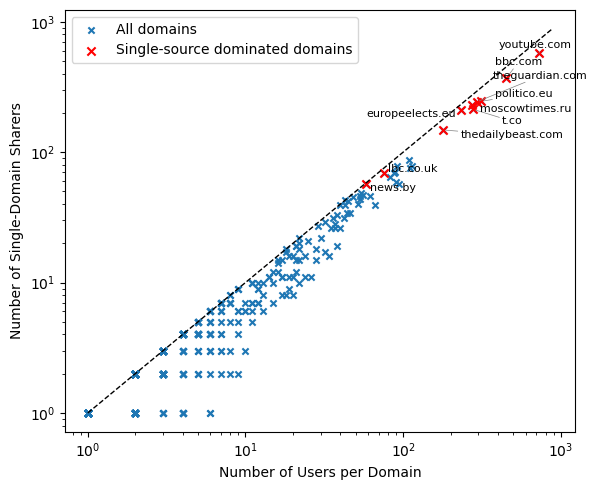

In [ ]:
edges = build_user_domain_edges_from_lists(
    moldova_df,
    user_col="twitterData.twitterAuthorScreenname",
    domains_col="domains_shared",
    normalize=True,
    drop_domains = {"x.com"}
)

stats = stats_from_edges(edges, user_col="twitterData.twitterAuthorScreenname")

plot_focus_high_x(stats, annotate_top=10, min_domain_deg=None, min_domain_deg_quantile=0.5) 